# Inversión Cinemática: Terremoto de Copiapó (06-06-2025)

Este notebook realiza la inversión utilizando los parámetros optimizados de AXITRA y el pre-procesador de datos con control de tiempo y padding.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
from obspy import UTCDateTime
import kdellipspy as kde

base_dir = Path("inversions/copiapo-06-06-2025")
input_ctl = base_dir / "input.ctl"


In [2]:
cfg = kde.ConfigParser()
print([i for i in dir(cfg) if not i.startswith("_")])


['ellipse', 'fault_plane', 'filepath', 'from_dict', 'get_base_template_path', 'inversion_params', 'inversion_process', 'moment_tensor', 'observed_data', 'parse', 'plot_stations', 'save', 'source_position', 'stations', 'update_stations', 'update_stations_from_sac', 'velocity_model']


En esta version se pueden configurar los parametros directamente desde python, sin necesidad de un archivo input.ctl

In [3]:
cfg.observed_data = kde.ObservedDataParams(
    t1=0.0,
    t2=128.0,
    npts=512,
    delta=0.25,
    units=2,
)

cfg.source_position = kde.SourcePosition(
    event_name="Event Copiapo 2025 INTRAPLATE",
    origin_time="2025-06-06T17:15:06.000Z",
    latitude=-26.639000,
    longitude=-70.404000,
    depth=75.000000,
    strike=72.000000,
    dip=47.000000,
    rake=-111.000000,
)

cfg.fault_plane = kde.FaultPlaneParams(
    lx=30000.0,
    ly=30000.0,
    hx=15000.0,
    hy=15000.0,
    nx=30,
    ny=30,
)

cfg.ellipse = kde.EllipseParams(
    num_ellipses=1,
    initial_slip=0,
    slip_shape=1,
    freq1=0.1,
    freq2=0.5,
    t0=2.0,
)

cfg.inversion_params = kde.InversionParams(
    parameters=[
        kde.InversionParam(name="Length of axis 1 (km)", min_val=2.0, max_val=15.0, flag=1),
        kde.InversionParam(name="Length of axis 2 (km)", min_val=2.0, max_val=15.0, flag=1),
        kde.InversionParam(name="Rotation angle (x pi)", min_val=0.0, max_val=1.0, flag=1),
        kde.InversionParam(name="Position of the center np", min_val=0.2, max_val=1.0, flag=1),
        kde.InversionParam(name="Position of the center tp (x 2pi)", min_val=0.0, max_val=1.0, flag=1),
        kde.InversionParam(name="Maximum slip (Dmax) (m)", min_val=0.5, max_val=6.0, flag=1),
        kde.InversionParam(name="Rupture velocity (Vr) (km/s)", min_val=1.5, max_val=3.0, flag=1),
    ]
)

cfg.inversion_process = kde.InversionProcessParams(
    algorithm_type=0, # 0: NA | 1: MCMC
    num_iterations=40, 
    ss1=200,
    ss_other=50,
    cells_resample=3,
    misfit_time_window=0.0,
    n_jobs=1,
)

cfg.moment_tensor = kde.MomentTensor(
    flag=1,
    mrr=-2.486000,
    mtt=7.932000,
    mpp=0.083000,
    mrt=0.038000,
    mrp=-0.739000,
    mtp=0.473000,
    exponent=18.0,
    scaling_mode="mt_factored",
)

cfg.stations = kde.StationParams(
    stations=[
        kde.ConfigStation(latitude=-26.148001, longitude=-70.598999, height=0.0, name="AC01", use_n=True, use_e=True, use_z=True),
        kde.ConfigStation(latitude=-27.104000, longitude=-70.848999, height=0.0, name="A02C", use_n=True, use_e=True, use_z=True),
        kde.ConfigStation(latitude=-27.422001, longitude=-70.260002, height=0.0, name="A29C", use_n=True, use_e=True, use_z=True),
        kde.ConfigStation(latitude=-28.205000, longitude=-71.073997, height=0.0, name="AC04", use_n=True, use_e=True, use_z=True),
        kde.ConfigStation(latitude=-28.836000, longitude=-70.274002, height=0.0, name="AC05", use_n=True, use_e=True, use_z=True),
        kde.ConfigStation(latitude=-29.101999, longitude=-71.410004, height=0.0, name="A32C", use_n=True, use_e=True, use_z=True),
        kde.ConfigStation(latitude=-23.905001, longitude=-69.291000, height=0.0, name="PB19", use_n=True, use_e=True, use_z=True),
        kde.ConfigStation(latitude=-29.879000, longitude=-71.271004, height=0.0, name="C16O", use_n=True, use_e=True, use_z=True),
    ]
)

cfg.velocity_model = kde.VelocityModel(
    layers=[
        kde.VelocityLayer(0.0, 5210.0, 2990.0, 2500.0, 600.0, 400.0),
        kde.VelocityLayer(2500.0, 5370.0, 3090.0, 2500.0, 600.0, 400.0),
        kde.VelocityLayer(4500.0, 5550.0, 3190.0, 2500.0, 600.0, 400.0),
        kde.VelocityLayer(6500.0, 5720.0, 3290.0, 2600.0, 600.0, 400.0),
        kde.VelocityLayer(8500.0, 5890.0, 3390.0, 2600.0, 600.0, 400.0),
        kde.VelocityLayer(10500.0, 5980.0, 3440.0, 2600.0, 600.0, 400.0),
        kde.VelocityLayer(15000.0, 6800.0, 3750.0, 2800.0, 600.0, 400.0),
        kde.VelocityLayer(20000.0, 6810.0, 3880.0, 2800.0, 600.0, 400.0),
        kde.VelocityLayer(25000.0, 6950.0, 3940.0, 3000.0, 600.0, 400.0),
        kde.VelocityLayer(30000.0, 6980.0, 4050.0, 3000.0, 600.0, 400.0),
        kde.VelocityLayer(35000.0, 7110.0, 4110.0, 3100.0, 600.0, 400.0),
        kde.VelocityLayer(40000.0, 7410.0, 4180.0, 3300.0, 600.0, 400.0),
        kde.VelocityLayer(45000.0, 7690.0, 4300.0, 3300.0, 600.0, 400.0),
        kde.VelocityLayer(50000.0, 8050.0, 4390.0, 3300.0, 600.0, 400.0),
        kde.VelocityLayer(60000.0, 8480.0, 4730.0, 3400.0, 600.0, 400.0),
        kde.VelocityLayer(70000.0, 8480.0, 4780.0, 3400.0, 600.0, 400.0),
    ]
)

print("Configuración base completada.")

Configuración base completada.


Ahora por ejemplo se puede observar las estaciones 

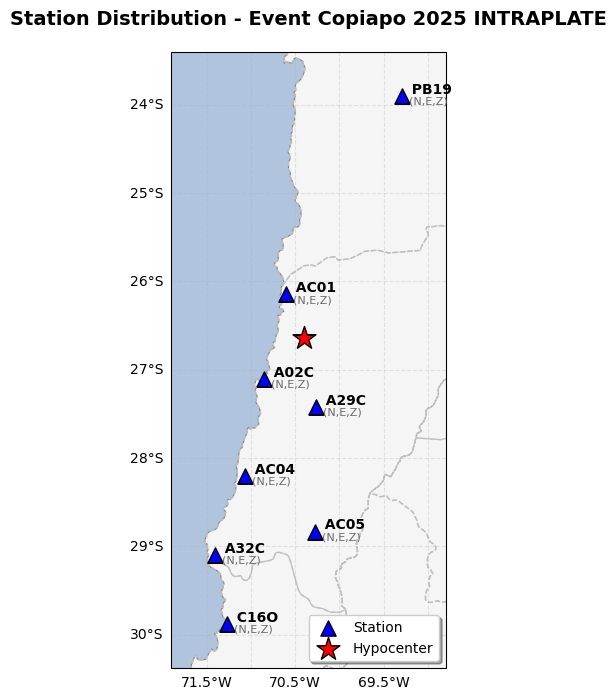

(<Figure size 1000x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Station Distribution - Event Copiapo 2025 INTRAPLATE'}>)

In [4]:
cfg.plot_stations()

## 1. Visualización Previa de SAC Files

Antes de procesar los archivos para la inversión, visualizamos las estaciones disponibles en la carpeta `RAW` usando el nuevo método del `DataPreprocessor`.

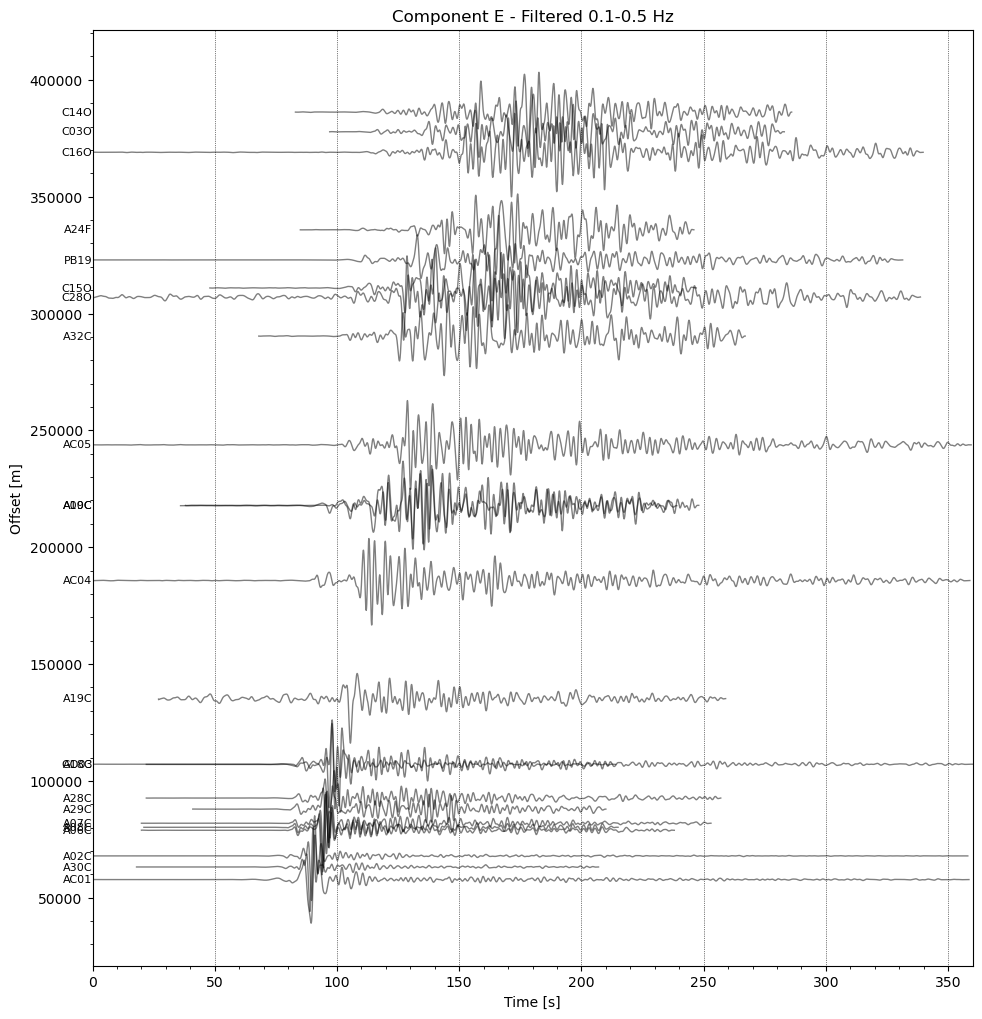

In [5]:
preprocessor = kde.DataPreprocessor(cfg)
raw_sac_dir =  "/home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/RAW/VELOCITY"

# Visualizar las componentes verticales filtradas entre 0.05 y 0.2 Hz
preprocessor.plot_record_section(
    raw_dir=raw_sac_dir,
    freqmin=0.1,
    freqmax=0.5,
    components=['E'],
    scale=2.0
)

## 2. Pre-procesamiento con Ventana de Tiempo y Padding

Definimos una ventana de tiempo explícita usando `UTCDateTime`. Si los datos crudos son más cortos, se rellenarán con ceros para cumplir con el `npts` requerido.

In [6]:
estaciones_configuradas = [s.name for s in cfg.stations.stations]
print("Estaciones configuradas:", estaciones_configuradas)

Estaciones configuradas: ['AC01', 'A02C', 'A29C', 'AC04', 'AC05', 'A32C', 'PB19', 'C16O']


In [7]:
output_dir = input_ctl.parent / "DATA_PROCESSED"

# Tiempo de origen del terremoto (definido en input.ctl)
origin_time = UTCDateTime(cfg.source_position.origin_time)
print(f"Tiempo de origen: {origin_time}")
t_end = origin_time + 128.0

# Procesar trazas: recortar y aplicar zero-padding si es necesario.
# Asumimos que los archivos en 'DATA' comienzan en el origin_time (data_start_time=origin_time).
processed_data = preprocessor.process_raw_files(
    raw_dir=raw_sac_dir,
    output_dir=output_dir,
    freq1=0.1,
    freq2=0.5,
    t_start=origin_time,    
    t_end=t_end,
    data_start_time=origin_time,
    units=2, # 2: vel (m/s)
    station_names=estaciones_configuradas # Opcional: filtrar estaciones
)

Tiempo de origen: 2025-06-06T17:15:06.000000Z
[signal_utils] WARNING: no instrument inventory found in DATA/RAW; response removal skipped.
✓ Saved: inversions/copiapo-06-06-2025/DATA_PROCESSED/real_vel_x (npts=512)
✓ Saved: inversions/copiapo-06-06-2025/DATA_PROCESSED/real_vel_y (npts=512)
✓ Saved: inversions/copiapo-06-06-2025/DATA_PROCESSED/real_vel_z (npts=512)


## 4. Inversión Neighbourhood Algorithm (NA)

In [8]:
data_dir = output_dir
print('cargando y filtrando datos procesados desde:', data_dir)
observed_waveforms, time_array = kde.load_and_filter_observed_data(config=cfg,
                                                                    data_dir=data_dir,prefer_raw = False)
azi_times_array = kde.build_azi_times_array(config = cfg)

cargando y filtrando datos procesados desde: inversions/copiapo-06-06-2025/DATA_PROCESSED


In [9]:
inversion = kde.NAInversionModel(config = cfg,
                                 observed_waveforms=observed_waveforms,
                                 time_array=time_array,
                                 azi_times_array=azi_times_array)
na_config = kde.NAConfig(
    n_samples_initial = 20,
    n_samples_iteration = 10,
    n_iterations = 5,
    n_cells_resample = 6,
    n_jobs = -1,
    random_seed = 42

)
result = inversion.run_na_search(na_config)

[NA] Adjusting n_samples_iteration from 10 to 12 to satisfy neighpy constraint (must be a multiple of n_cells_resample=6).


[NA] Starting search: ni=20, ns=12, n=5, nr=6 -> expected evaluations=80 (n_jobs=-1)
NAI - Initial Random Search


NAI - Optimisation Loop:   0%|          | 0/5 [01:05<?, ?it/s]


KeyboardInterrupt: 

Inversion results saved to output/inversion_result.joblib


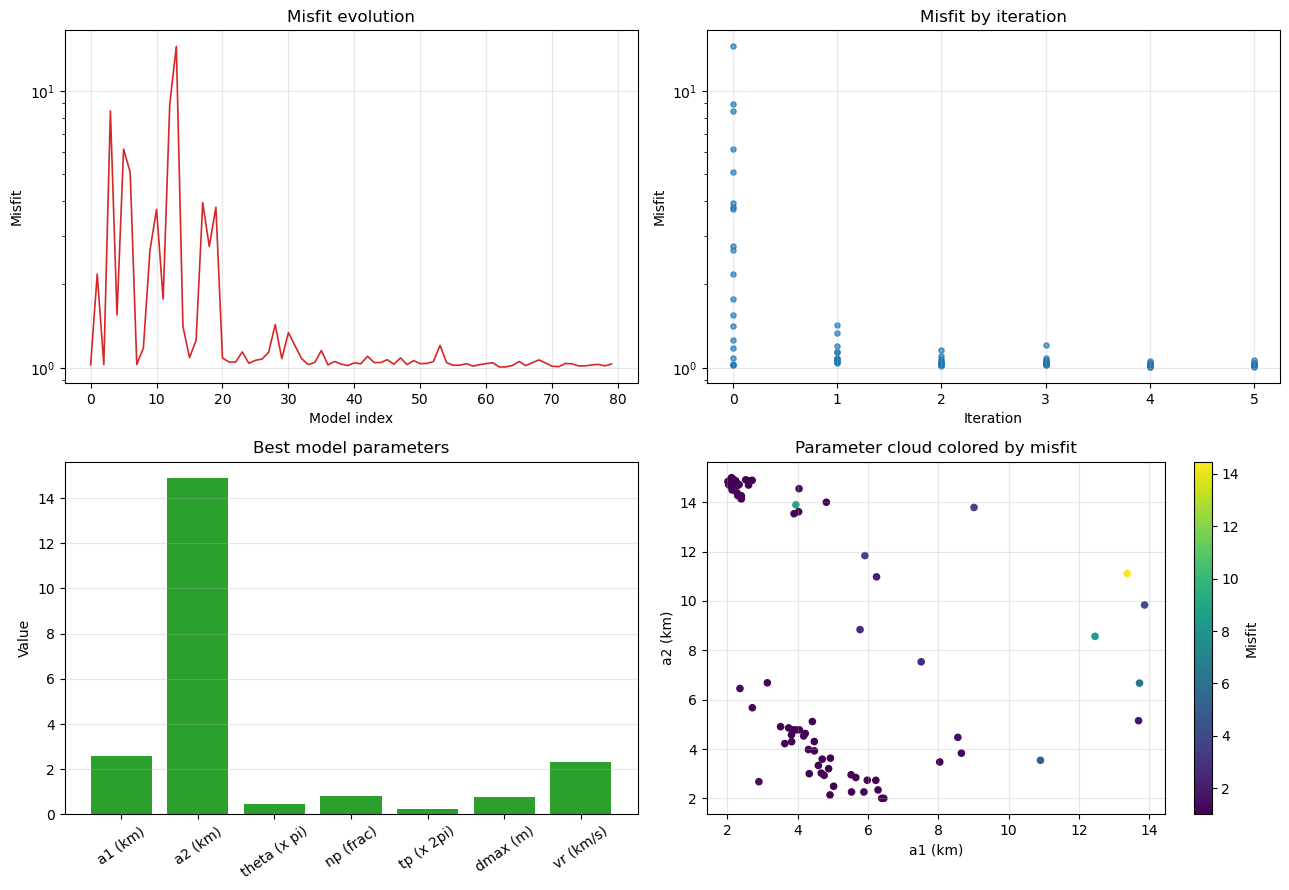

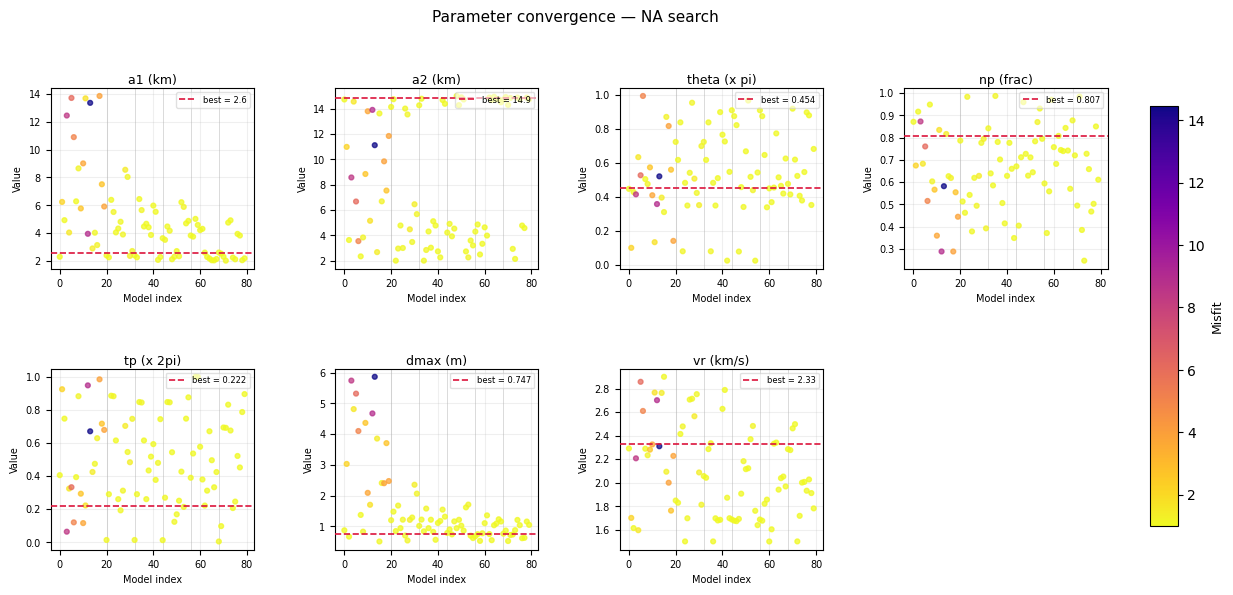

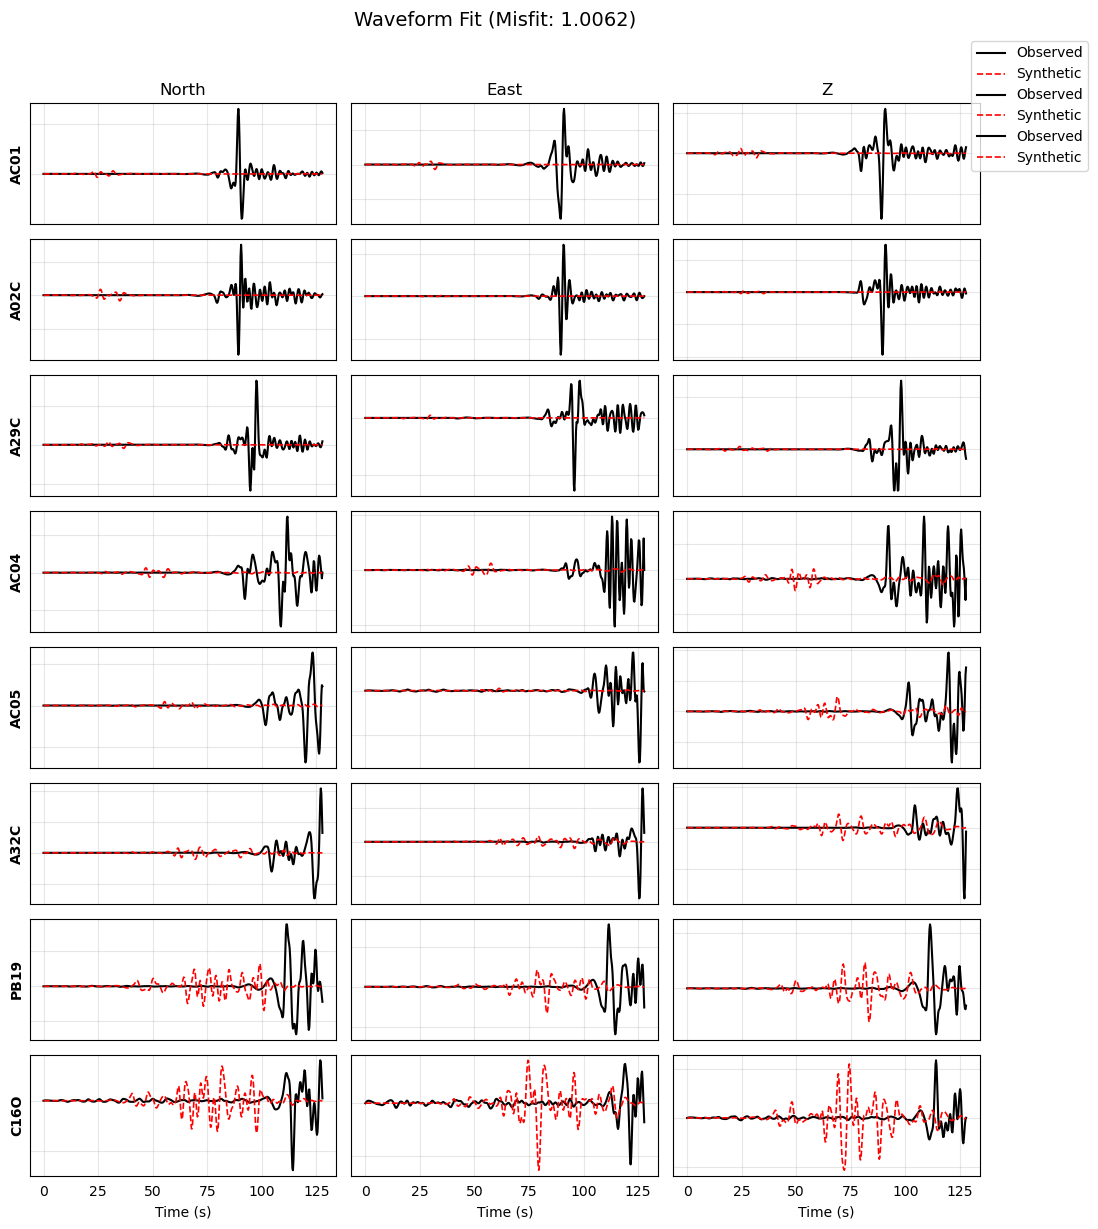

(<Figure size 1000x1200 with 24 Axes>,
 array([[<Axes: title={'center': 'North'}, ylabel='AC01'>,
         <Axes: title={'center': 'East'}>, <Axes: title={'center': 'Z'}>],
        [<Axes: ylabel='A02C'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='A29C'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='AC04'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='AC05'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='A32C'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='PB19'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='Time (s)', ylabel='C16O'>,
         <Axes: xlabel='Time (s)'>, <Axes: xlabel='Time (s)'>]],
       dtype=object))

In [ ]:
os.makedirs('./output', exist_ok=True)
result.save('./output/inversion_result.joblib')
result.plot(show=True, save_path='./output/na_results.png')
result.plot_convergence(show=True, save_path='./output/parameter_convergence.png')
result.plot_fit(show=True, save_path='./output/waveform_fit.png')